# Practice 1: Regression

**DS-GA 3001 Visualization for Machine Learning — Week 4 Lab (Sept 29, 2026)**

In this notebook we train a linear regression model and a generalized additive model (GAM)
on the California housing data, and we visualize each one to interpret its behavior.

The question running through both practices is the same: *what can we see about a model
that we cannot read off a single accuracy number?*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
cal_housing = fetch_california_housing()
X = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
y = cal_housing.target

In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


### Look at the target before modelling anything

`y` is the median house value of a district, in units of $100,000.

In [6]:
print(pd.Series(y, name="MedHouseVal").describe())
print(f"\nrows sitting exactly at the ceiling: {(y >= 5.0).sum()} of {len(y)} ({(y >= 5.0).mean():.1%})")

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

rows sitting exactly at the ceiling: 992 of 20640 (4.8%)


The maximum is exactly 5.00001, not a coincidence: the target was **capped** when the dataset was
built, so every district worth more than $500,000 is recorded at the same value. About one row in
twenty sits on that ceiling.

Two consequences to keep in mind for the rest of the notebook:

- it shows up as a **horizontal stripe** along the top of the scatterplots below;
- **no model here can predict above 5**, so part of the error we are about to measure is baked
  into the data rather than the model.

In [7]:
df = pd.DataFrame(data=X.values, columns=X.columns)
df['y_true'] = y

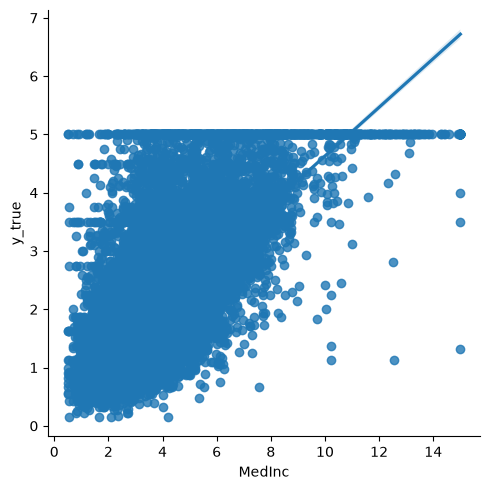

In [8]:
sns.lmplot(x="MedInc", y="y_true", data=df)

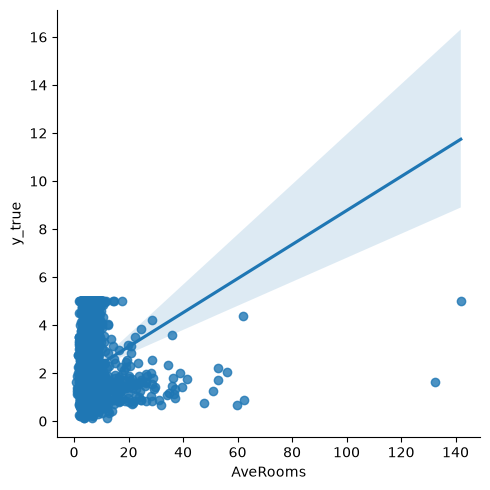

In [9]:
sns.lmplot(x="AveRooms", y="y_true", data=df)

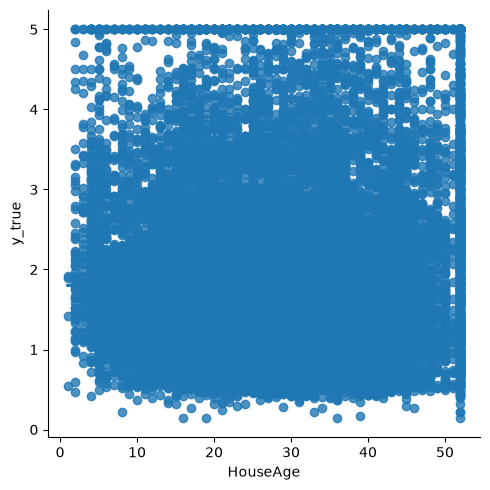

In [10]:
sns.lmplot(x="HouseAge", y="y_true", data=df)

## Train / test split

Everything from here on is **fitted on the training set and reported on both sets**.

A score computed on the same rows the model was fitted to is not an estimate of anything: we saw
last week that a model can reach perfect training accuracy and still be useless. We use the same
split as Practice 2 so the two notebooks are comparable.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print("train", X_train.shape, " test", X_test.shape)

train (13828, 8)  test (6812, 8)


## Linear Model

In [12]:
'''train the linear regression model'''
from sklearn import linear_model

reg = linear_model.LinearRegression()

reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.44, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [13]:
reg.coef_

array([ 4.44870466e-01,  9.55004561e-03, -1.21991503e-01,  7.79144696e-01,
       -7.68990809e-08, -3.29948505e-03, -4.19131153e-01, -4.34103468e-01])

In [14]:
cof_df = pd.DataFrame(data=reg.coef_.reshape(1,-1), columns=X.columns)
cof_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.44487,0.00955,-0.121992,0.779145,-7.689908e-08,-0.003299,-0.419131,-0.434103


One number per feature. That is the whole visual story a linear model has to tell, and it is the
baseline the GAM has to beat.

In [15]:
'''report the performance of the linear model, on train and on test'''
from sklearn.metrics import mean_absolute_error, r2_score

for name, Xs, ys in [("train", X_train, y_train), ("test", X_test, y_test)]:
    pred = reg.predict(Xs)
    print(f"{name:5s}  MAE {mean_absolute_error(ys, pred):.4f}   R2 {r2_score(ys, pred):.4f}")

train  MAE 0.5295   R2 0.6094
test   MAE 0.5296   R2 0.5970


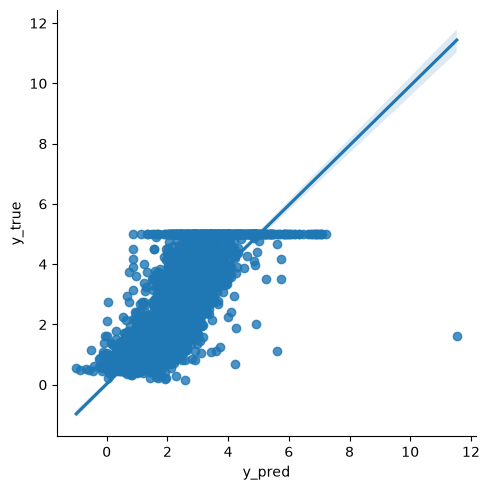

In [16]:
'''predicted against true, on the held-out test set'''
test_df = pd.DataFrame({"y_pred": reg.predict(X_test), "y_true": y_test})
sns.lmplot(x="y_pred", y="y_true", data=test_df);

The ceiling is visible again as the flat line of points across the top, and the model happily
predicts values above 5 that cannot occur.

## GAMs

What can we visualize for a Generalized Additive Model?

GAMs are usually in a format of:

$g(y) = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots + f_M(x_M)$

Each feature gets its own **curve** instead of its own single coefficient. We can use a
Partial Dependency Plot (PDP) to visualize how each feature influences the result.

In [17]:
!pip install pygam

zsh:1: command not found: pip


In [18]:
from pygam import LinearGAM, s

- `s()`: spline terms (a spline is a function defined piece-wise by polynomials)

For this regression problem, we can train a linear GAM which models:

$\mathbb{E}[y \mid X] = \beta_0 + f_1(X_1) + f_2(X_2) + \cdots + f_M(X_M)$

`gridsearch` fits the model many times over a grid of smoothing penalties and keeps the best one,
so this cell takes a few seconds.

In [19]:
gam = LinearGAM(n_splines=25).gridsearch(X_train.values, y_train, progress=False)
print("done")

done


In [20]:
for name, Xs, ys in [("train", X_train, y_train), ("test", X_test, y_test)]:
    print(f"{name:5s}  R2 {r2_score(ys, gam.predict(Xs.values)):.4f}")

train  R2 0.7350
test   R2 0.6942


Compare the **test** R2 with the linear model's test R2. The GAM is genuinely better.

Now compare each model's own two numbers. The linear model scores almost the same on train and
test, because a straight line has very little capacity to memorise. The GAM's training score is
noticeably higher than its test score: the extra flexibility that lets it fit curves is also
flexibility it can waste on noise. Neither gap is alarming here, but only one of the two models
has a gap at all, and you would not know that from a single number.

- How do we understand each "smooth function"?

- Partial Dependency Plot!

sklearn and interpret_ml provide PDP visualization functions.
pygam provides the function to calculate the results for plotting a PDP.

In each plot below the x axis is one feature and the y axis is **that feature's additive
contribution** to the prediction, with the other features held fixed. The dashed red lines are the
**95% confidence interval** of the fitted curve, which is what `width=.95` returns. Where the two
dashed lines spread apart there is little data, and the shape of the curve there should not be
trusted.

In [21]:
XX = gam.generate_X_grid(term=0)
XX

array([[ 0.4999    ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.64636667,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.79283333,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.9393    ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 1.08576667,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 1.23223333,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 1.3787    ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 1.52516667,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 1.67163333,  0.        

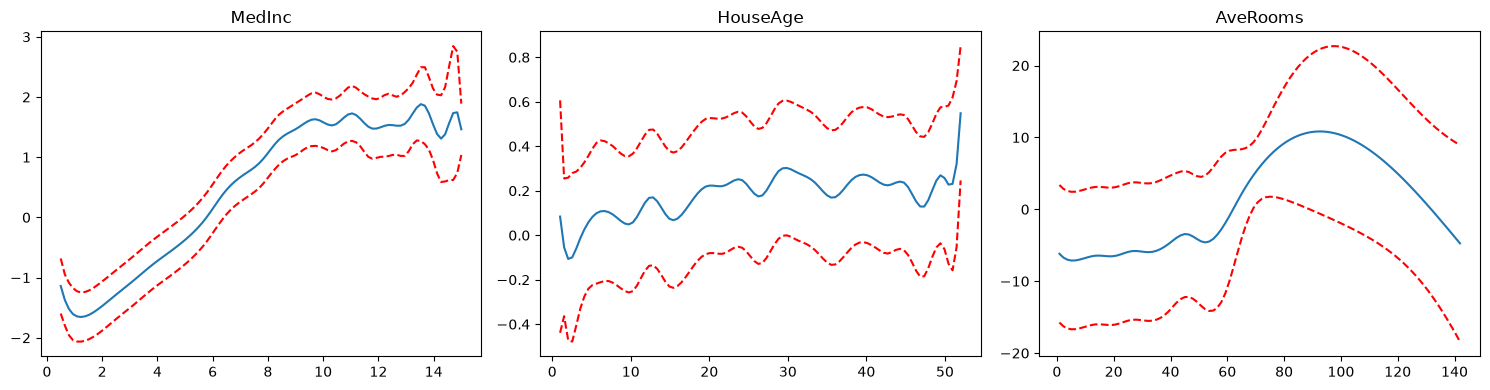

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

col = [0, 1, 2]
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=col[i]) # grid that varies column col[i] and holds the others at their median
    ax.plot(XX[:, col[i]], gam.partial_dependence(term=col[i], X=XX))
    ax.plot(XX[:, col[i]], gam.partial_dependence(term=col[i], X=XX, width=.95)[1], c='r', ls='--')

    ax.set_title(X.columns[col[i]])

plt.tight_layout()
plt.show()

### All eight terms

Those three are the ones everybody looks at first. The two most interesting terms in this dataset
are **Latitude** and **Longitude**: between them they encode how close a district is to the coast
and to a city, which is something no single coefficient in the linear model could express.

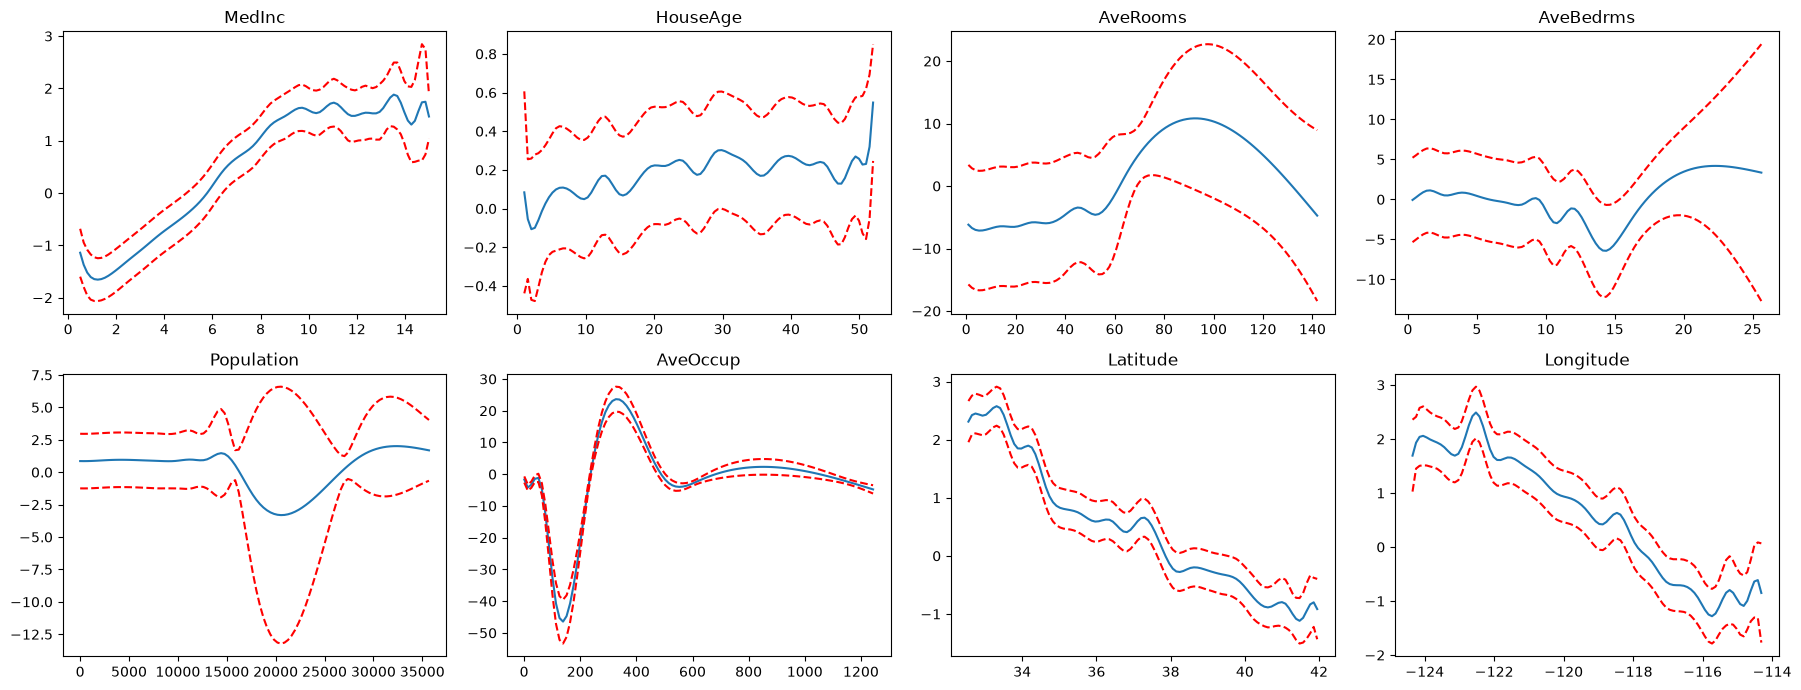

In [23]:
fig, axs = plt.subplots(2, 4, figsize=(18, 7))

for i, ax in enumerate(axs.ravel()):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')

    ax.set_title(X.columns[i])

plt.tight_layout()
plt.show()

### Your turn

1. Look at the PDP for `AveBedrms`. The curve is nearly flat across the range where most districts
   sit, then swings hard at the right edge. What do the dashed lines tell you about that swing, and
   would you report it as a finding?

2. Refit with `n_splines=5` and again with `n_splines=50`. What happens to the shape of the curves,
   and what happens to the **test** R2? Which of the two changes would you have missed if you only
   looked at the training score?

3. The linear model gives one number per feature and the GAM gives one curve per feature. For which
   of the eight features does that difference actually change the story?

In [24]:
# your code here